# Evaluate Custom Binary UNet Model (epoch_883)

This notebook evaluates your custom-trained UNet model that directly predicts binary comb masks.

**Model:** epoch_883.pth  
**Output:** 0 = background, 1 = comb (direct binary output, no post-processing needed)

In [1]:
%load_ext autoreload
%autoreload 2

## Setup

In [2]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from honeybee_comb_inferer.inference import HoneyBeeCombInferer
from segmentation_restruct.comb_limitor import CombMaskEvaluator

## Configuration

In [3]:
root_dir = Path().cwd().resolve().parent.parent
model_dir = root_dir / 'models'
model_name = 'combSegmentor'  # Your custom binary model
device = 'cuda'

# Binary label classes config (for visualization)
label_classes_binary = root_dir / 'data' / 'label_classes_binary.json'

# Test data paths
images_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\test")
gt_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\labels\test")

print(f"Model: {model_name}")
print(f"Architecture: UNet + EfficientNet-B0")
print(f"Classes: 1 (binary)")
print(f"Device: {device}")
print(f"Test images: {images_dir}")
print(f"Ground truth: {gt_dir}")

Model: combSegmentor
Architecture: UNet + EfficientNet-B0
Classes: 1 (binary)
Device: cuda
Test images: E:\Bachelorarbeit\comb_limitation_dataset\images\test
Ground truth: E:\Bachelorarbeit\comb_limitation_dataset\labels\test


## Load Model

**Architecture:** UNet with EfficientNet-B0 encoder  
**Classes:** 1 (binary segmentation)  
**Output:** 0 = background, 1 = comb

In [4]:
# Load your custom binary model
model = HoneyBeeCombInferer(
    model_name=model_name,
    path_to_pretrained_models=str(model_dir),
    label_classes_config=str(label_classes_binary),  # Binary config: 1 class (honeycomb)
    device=device
)

print("✓ Model loaded successfully")
print(f"  Model output classes: {model.num_classes}")
print(f"  Label config classes: 1 (honeycomb)")
print(f"  Output format: 0=background, 1=comb")

✓ Model loaded successfully
  Model output classes: 2
  Label config classes: 1 (honeycomb)
  Output format: 0=background, 1=comb


## Test on Single Image

In [5]:
# Get first test image
test_image = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\test\20240529_cam-2.png")

if not test_image.exists():
    # Find first available image
    test_images = sorted(images_dir.glob("*.png")) + sorted(images_dir.glob("*.jpg"))
    if test_images:
        test_image = test_images[0]
    else:
        raise FileNotFoundError(f"No images found in {images_dir}")

print(f"Testing with: {test_image.name}")

Testing with: 20240606_cam-3.png


In [6]:
# Run inference - model outputs values 0 or 1 directly
pred_mask = model.infer(image=str(test_image))

print(f"Prediction shape: {pred_mask.shape}")
print(f"Unique values: {np.unique(pred_mask)}")
print(f"Comb coverage: {np.mean(pred_mask) * 100:.1f}%")

Prediction shape: (4608, 5312)
Unique values: [0 1]
Comb coverage: 60.5%


In [7]:
# Load input image and ground truth
input_img = cv2.imread(str(test_image), cv2.IMREAD_GRAYSCALE)

gt_path = gt_dir / test_image.name
if not gt_path.exists():
    gt_path = gt_dir / test_image.with_suffix('.png').name

if gt_path.exists():
    gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
    gt_mask = (gt_mask > 0).astype(np.uint8)  # Ensure binary
    print(f"✓ Loaded ground truth: {gt_path.name}")
else:
    print(f"⚠ Ground truth not found: {gt_path}")
    gt_mask = None

✓ Loaded ground truth: 20240606_cam-3.png


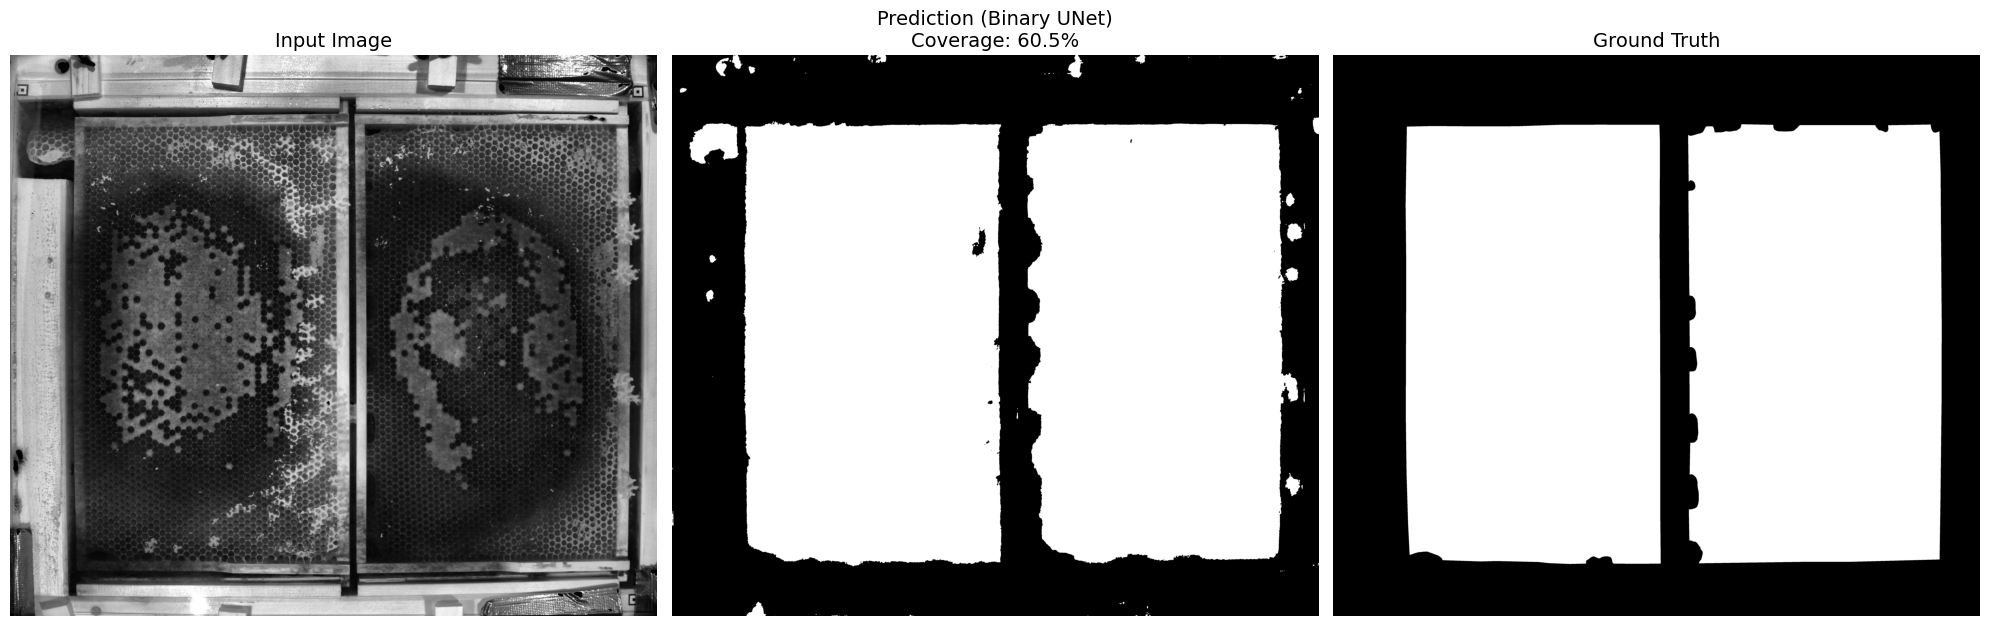

In [8]:
# Visualize: Input, Prediction, Ground Truth
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(input_img, cmap='gray')
axes[0].set_title('Input Image', fontsize=14)
axes[0].axis('off')

axes[1].imshow(pred_mask, cmap='gray')
axes[1].set_title(f'Prediction (Binary UNet)\nCoverage: {np.mean(pred_mask)*100:.1f}%', fontsize=14)
axes[1].axis('off')

if gt_mask is not None:
    axes[2].imshow(gt_mask, cmap='gray')
    axes[2].set_title('Ground Truth', fontsize=14)
    axes[2].axis('off')
else:
    axes[2].text(0.5, 0.5, 'No Ground Truth', ha='center', va='center', fontsize=14)
    axes[2].axis('off')

plt.tight_layout()
plt.show()

## Evaluate Single Image


             Custom Binary UNet - Single Image              

Main Metrics:
Accuracy:    0.9765  (97.65%)
IoU:         0.9618  (96.18%)
Dice:        0.9806  (98.06%)
F1 Score:    0.9806  (98.06%)

Precision & Recall:
Precision:   0.9780  (97.80%)
Recall:      0.9831  (98.31%)
Specificity: 0.9665  (96.65%)

Confusion Matrix:
True Positives  (TP): 14,494,032
True Negatives  (TN): 9,408,690
False Positives (FP): 326,367
False Negatives (FN): 248,607
Total pixels:         24,477,696



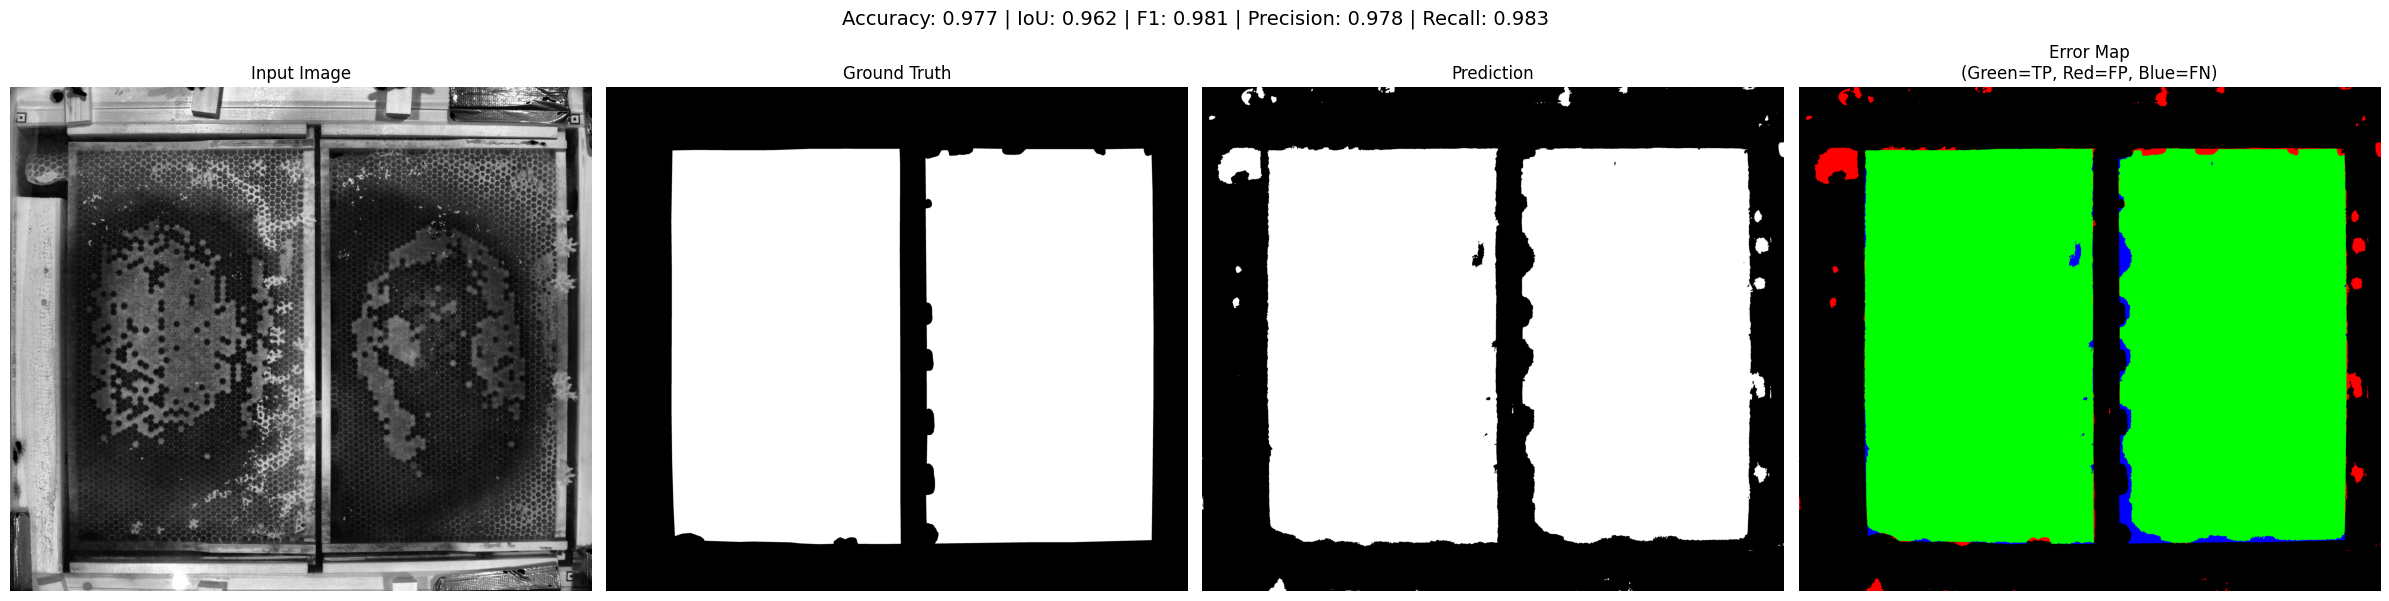

In [9]:
if gt_mask is not None:
    evaluator = CombMaskEvaluator()
    metrics = evaluator.evaluate(pred_mask, gt_mask)

    evaluator.print_metrics(metrics, title="Custom Binary UNet - Single Image")

    # Visualize with error map
    fig, axes = evaluator.visualize_prediction(
        pred_mask,
        gt_mask,
        input_image=input_img,
        show_metrics=True
    )
    plt.show()
else:
    print("⚠ Skipping evaluation - no ground truth available")

## Batch Processing and Evaluation

In [10]:
# Find all test images with ground truth
image_files = sorted(images_dir.glob("*.png")) + sorted(images_dir.glob("*.jpg"))
print(f"Found {len(image_files)} images to process")

predicted_masks = []
ground_truth_masks = []
input_images = []
image_names = []

print("\nProcessing images...")
for img_file in image_files:
    # Find corresponding ground truth
    gt_file = gt_dir / img_file.name
    if not gt_file.exists():
        gt_file = gt_dir / img_file.with_suffix('.png').name

    if not gt_file.exists():
        print(f"Skipping {img_file.name} - no ground truth found")
        continue

    print(f"Processing {img_file.name}...")

    # Load input
    input_img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)

    # Run inference - binary output directly
    pred_mask = model.infer(str(img_file))

    # Load ground truth
    gt_mask = cv2.imread(str(gt_file), cv2.IMREAD_GRAYSCALE)
    gt_mask = (gt_mask > 0).astype(np.uint8)

    predicted_masks.append(pred_mask)
    ground_truth_masks.append(gt_mask)
    input_images.append(input_img)
    image_names.append(img_file.name)

print(f"\n✓ Processed {len(predicted_masks)} images successfully")

Found 4 images to process

Processing images...
Processing 20240606_cam-3.png...
Processing background_cam-0_20250719T012105.601863.038Z.png...
Processing background_cam-0_20250719T012105.601863.038Z.png...
Processing background_cam-3_20250705T043209.571836.965Z.png...
Processing background_cam-3_20250705T043209.571836.965Z.png...
Processing k_background_cam-1_20250816T104412.249021.386Z--20250816T104512.171084.576Z.png...
Processing k_background_cam-1_20250816T104412.249021.386Z--20250816T104512.171084.576Z.png...

✓ Processed 4 images successfully

✓ Processed 4 images successfully


## Batch Evaluation

In [11]:
# Evaluate all masks
evaluator = CombMaskEvaluator()

aggregate_metrics, per_image_metrics = evaluator.evaluate_batch_from_arrays(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names
)

# Print aggregate results
print("\n" + "="*60)
print("CUSTOM BINARY UNET (epoch_883) - EVALUATION RESULTS")
print("="*60)
evaluator.print_metrics(aggregate_metrics, title="Aggregate Metrics")

# Print per-image results
print("\n" + "="*60)
print("Per-Image Results:")
print("="*60)
for metrics in per_image_metrics:
    print(f"\n{metrics['filename']}:")
    print(f"  IoU: {metrics['iou']:.4f}  |  Dice: {metrics['dice']:.4f}  |  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}  |  Recall: {metrics['recall']:.4f}")


CUSTOM BINARY UNET (epoch_883) - EVALUATION RESULTS

                     Aggregate Metrics                      

Aggregate Statistics (n=4 images):

  Main Metrics:
IoU:      0.9691 +/- 0.0078  (range: 0.9618 - 0.9816)
Dice/F1:  0.9843 +/- 0.0040  (range: 0.9806 - 0.9907)
Accuracy: 0.9802 +/- 0.0039  (range: 0.9765 - 0.9868)

  Precision & Recall:
Precision:   0.9833 +/- 0.0043  (range: 0.9780 - 0.9892)
Recall:      0.9853 +/- 0.0055  (range: 0.9776 - 0.9922)
Specificity: 0.9698 +/- 0.0080  (range: 0.9588 - 0.9802)

  Confusion Matrix Totals:
True Positives  (TP): 61,923,880  (avg: 15,480,970 per image)
True Negatives  (TN): 34,049,247  (avg: 8,512,312 per image)
False Positives (FP): 1,043,171  (avg: 260,793 per image)
False Negatives (FN): 894,486  (avg: 223,622 per image)
Total pixels:         97,910,784


Per-Image Results:

20240606_cam-3.png:
  IoU: 0.9618  |  Dice: 0.9806  |  Accuracy: 0.9765
  Precision: 0.9780  |  Recall: 0.9831

background_cam-0_20250719T012105.601863.038Z

## Save Results

In [15]:
# Create run name with timestamp
date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = f"custom_binary_unet_epoch883_{date_str}"

print(f"Run name: {run_name}")

# Save batch results
saved_paths = evaluator.save_batch_results(
    aggregate_metrics=aggregate_metrics,
    per_image_metrics=per_image_metrics,
    output_dir=root_dir / "results",
    run_name=run_name,
    save_figure=True,
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    input_images=input_images,
    image_names=image_names
)

print("\n✓ Results saved:")
for key, path in saved_paths.items():
    print(f"  {key}: {path}")

Run name: custom_binary_unet_epoch883_2025-11-01_13-21-00
✓ Aggregate metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\custom_binary_unet_epoch883_2025-11-01_13-21-00\aggregate_metrics.json
✓ Per-image metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\custom_binary_unet_epoch883_2025-11-01_13-21-00\per_image_metrics.json
✓ Visualization saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\custom_binary_unet_epoch883_2025-11-01_13-21-00\visualization.png
✓ Summary saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\custom_binary_unet_epoch883_2025-11-01_13-21-00\summary.txt

All results saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\custom_binary_unet_epoch883_2025-11-01_13-21-00


✓ Results saved:
  aggregate: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentati

## Visualize Batch Results

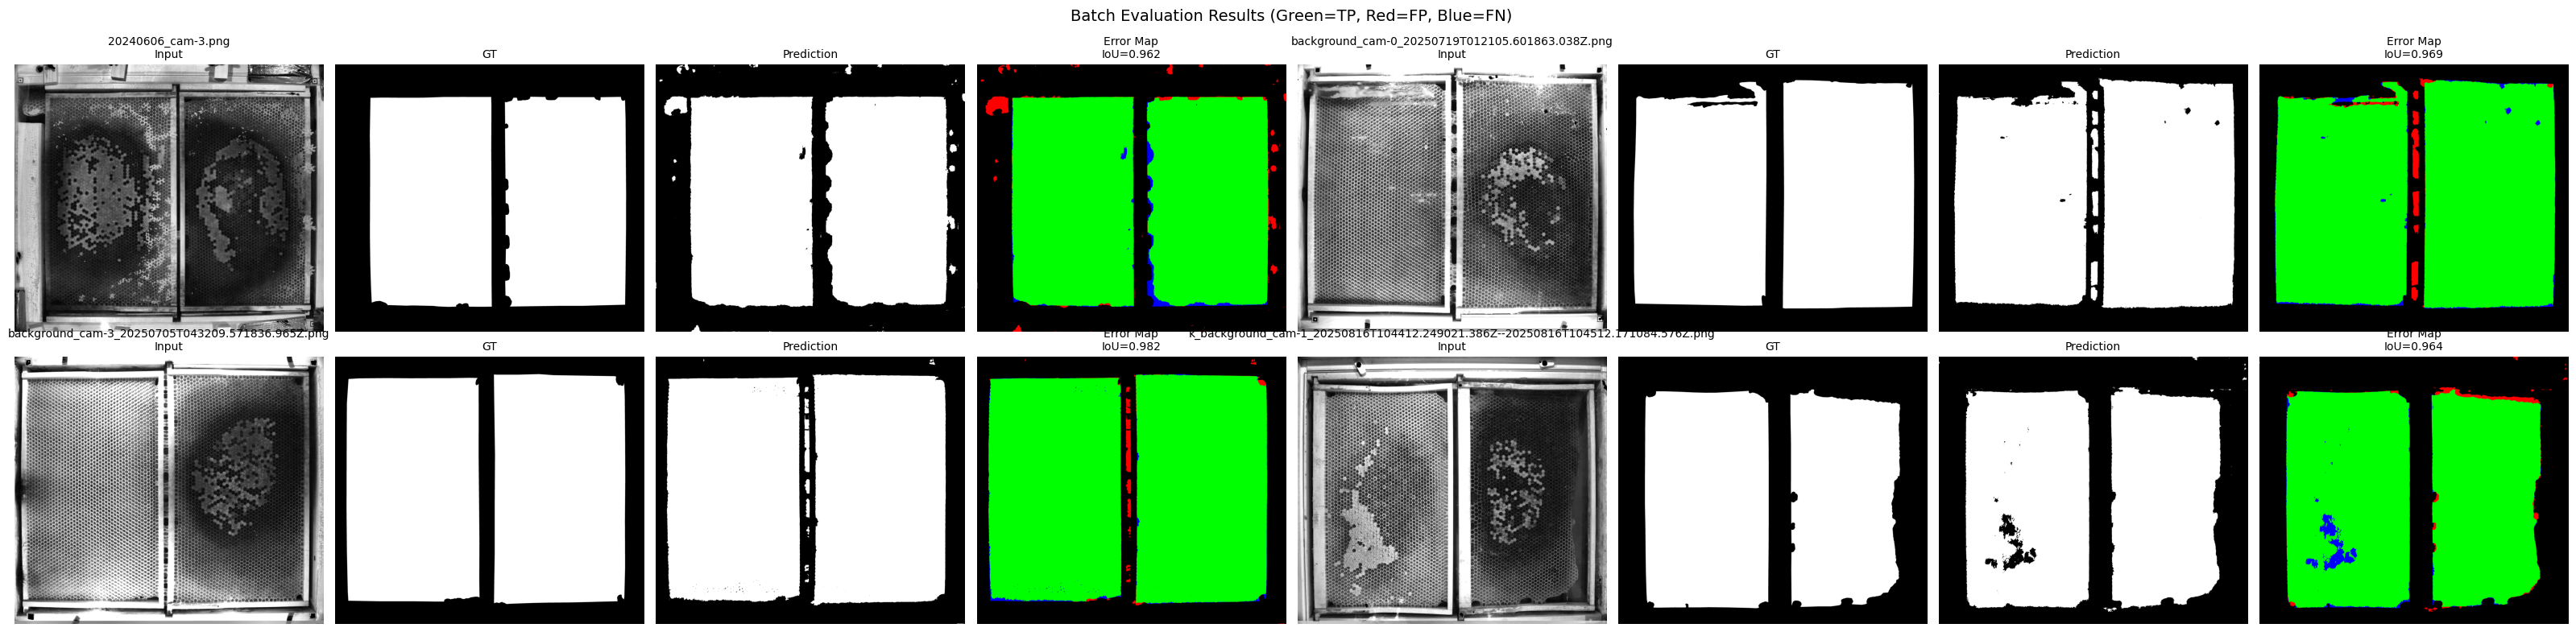

In [12]:
# Visualize all predictions in a grid
fig, axes = evaluator.visualize_batch(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names,
    input_images=input_images,
    max_cols=2
)
plt.show()

## Generate Individual Plots for Thesis

Each sample gets its own clean figure (no titles, no names) - ready for your thesis.

Generated 4 individual figures


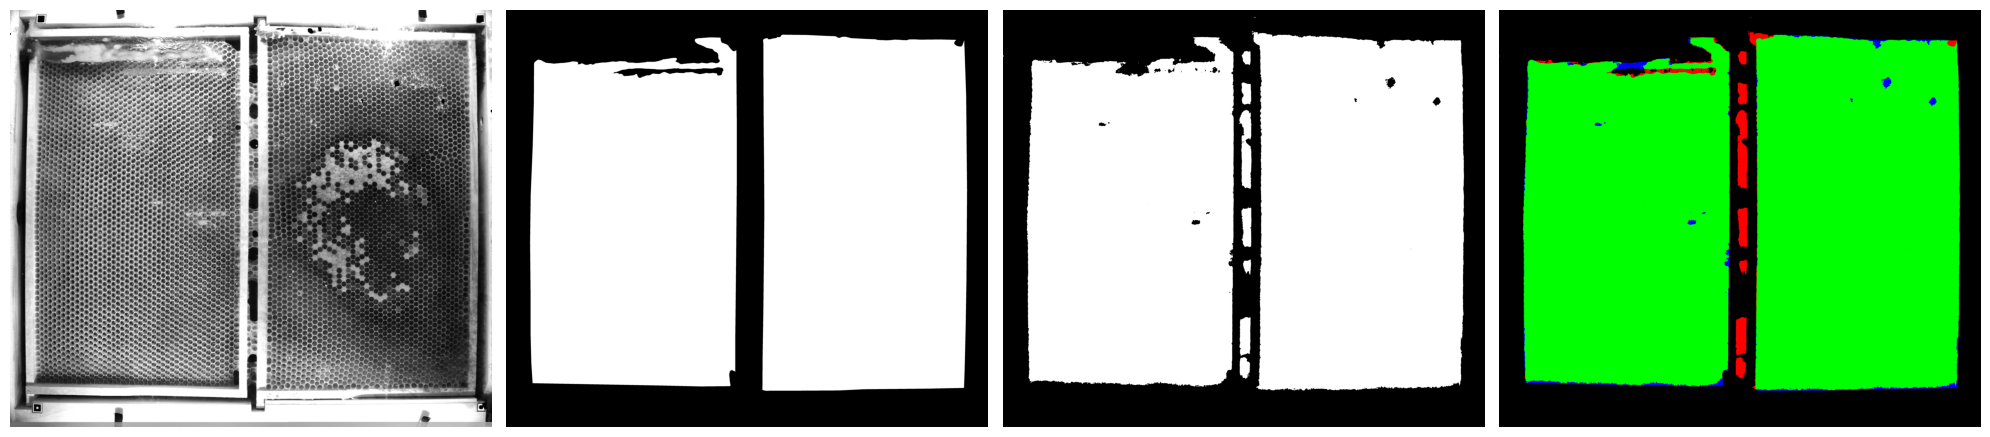

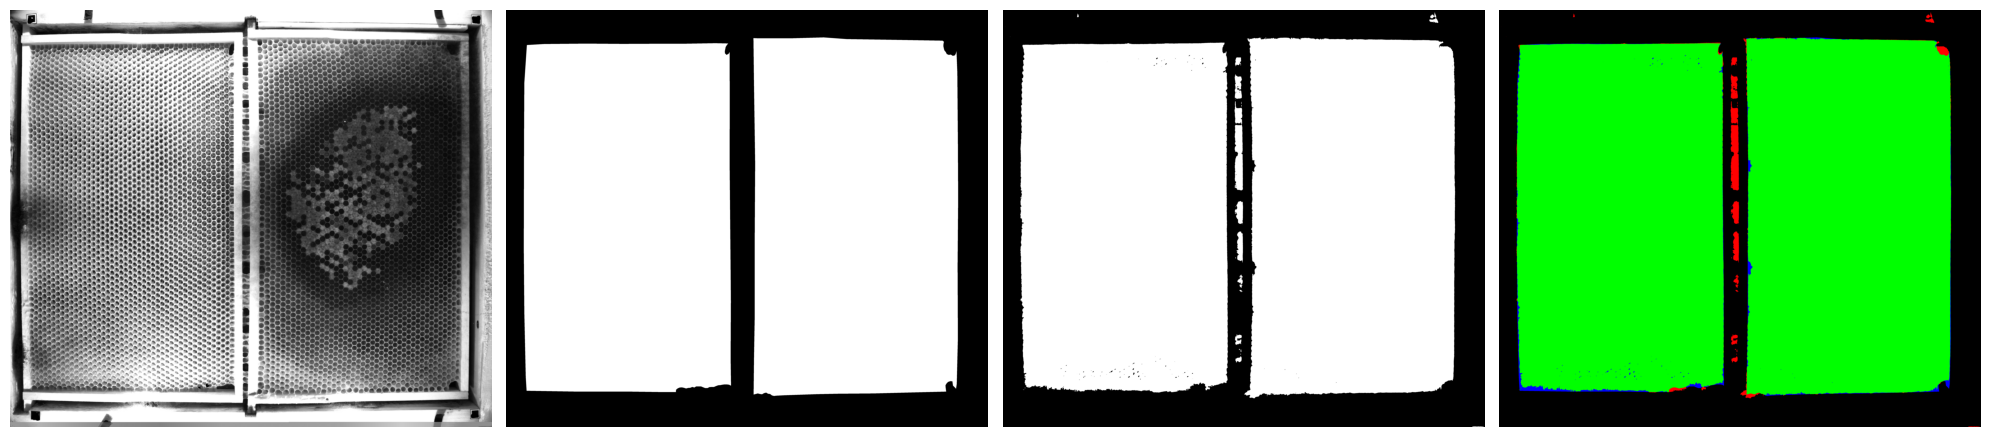

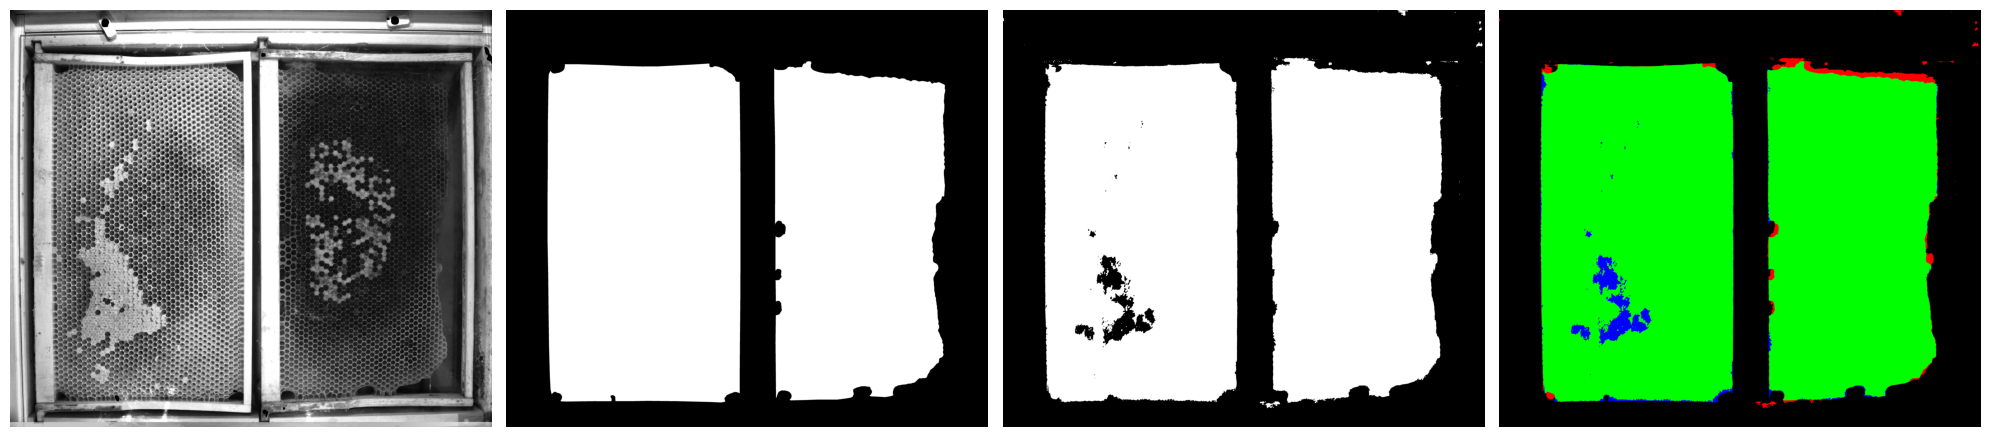

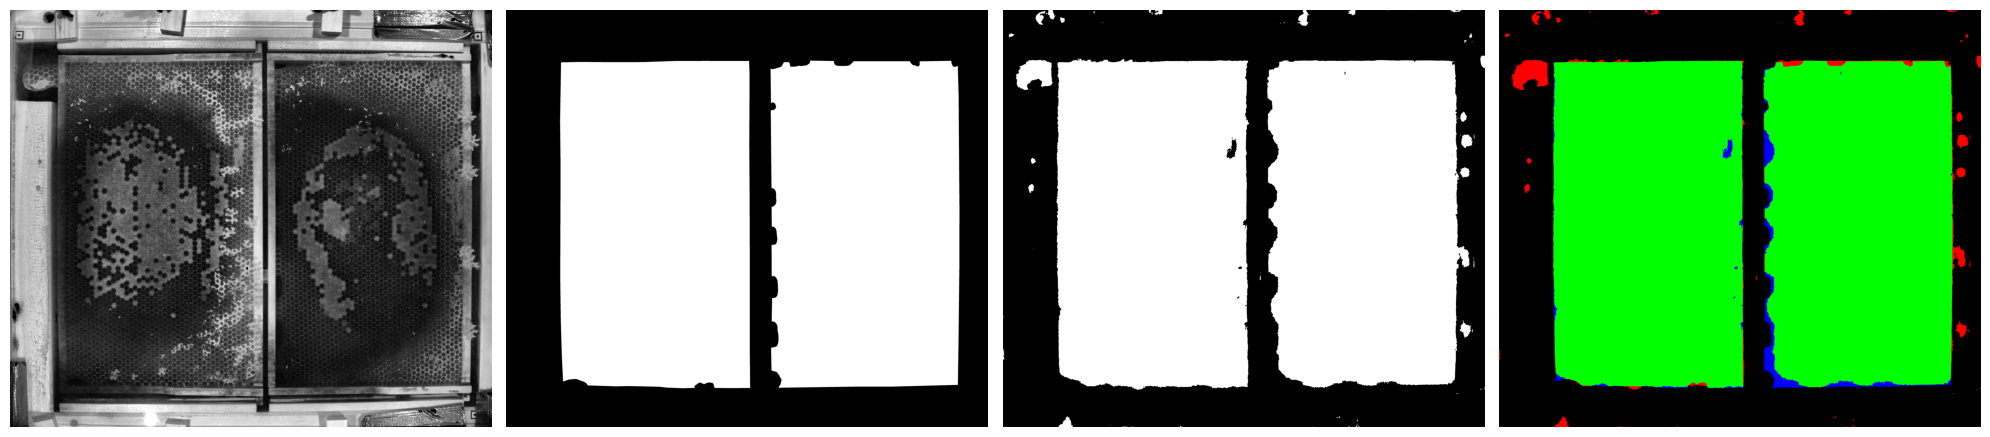

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [13]:
# Generate individual plots for each sample (thesis-ready, no titles/names)
individual_figures = evaluator.visualize_individual_samples(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    input_images=input_images,
    figsize_per_subplot=(5, 5)  # Adjust size as needed
)

print(f"Generated {len(individual_figures)} individual figures")

# Display all figures
for i, (fig, axes) in enumerate(individual_figures):
    plt.figure(fig.number)
    plt.show()

## Save Individual Figures (High Quality for Thesis)

In [14]:
# Save each figure individually with high DPI for thesis
thesis_figures_dir = root_dir / "thesis_figures"
thesis_figures_dir.mkdir(exist_ok=True)

for i, (fig, axes) in enumerate(individual_figures):
    # Save with high quality
    output_path = thesis_figures_dir / f"sample_{i+1}.png"
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path.name}")

    # Close to free memory
    plt.close(fig)

print(f"\n✓ All {len(individual_figures)} figures saved to: {thesis_figures_dir}")

Saved: sample_1.png
Saved: sample_2.png
Saved: sample_2.png
Saved: sample_3.png
Saved: sample_3.png
Saved: sample_4.png

✓ All 4 figures saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\thesis_figures
Saved: sample_4.png

✓ All 4 figures saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\thesis_figures


## Summary

**Model:** Custom Binary UNet (epoch_883.pth)  
**Output:** Direct binary masks (0=background, 1=comb)  
**No post-processing:** Model directly outputs final masks  
**Evaluation:** Complete metrics saved to results folder